# Neural ground state for the 1D harmonic oscillator

This notebook is an explanatory layer over the `adjoint_qm` library. It benchmarks a parity-even Gaussian-envelope neural wavefunction against exact harmonic oscillator results.

In [19]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in (cwd, *cwd.parents):
    src = candidate / "src"
    if src.exists():
        if str(src) not in sys.path:
            sys.path.insert(0, str(src))
        break

import torch
import matplotlib.pyplot as plt

import importlib
import adjoint_qm
import adjoint_qm.time_evolution
importlib.reload(adjoint_qm.time_evolution)
importlib.reload(adjoint_qm)

from adjoint_qm import (
    GaussianEnvelopeMLP,
    HarmonicOscillatorPotential,
    exact_harmonic_benchmarks,
    harmonic_correlator,
    quadrature_observables,
    train_quadrature,
    trapezoid_grid,
)

torch.set_default_dtype(torch.float64)

The ansatz is

$$
\log \psi_\theta(x) = -\frac12 \alpha x^2 + f_\theta(x^2),\qquad \alpha>0.
$$

The input feature $x^2$ enforces parity evenness, as required for the ground state of the quadratic potential.

In [7]:
omega = 1.0
torch.manual_seed(1234)

potential = HarmonicOscillatorPotential(omega=omega)
grid, weights = trapezoid_grid(x_max=8.0, n_grid=2001)
model = GaussianEnvelopeMLP(dim=1, hidden_layers=(32, 32), init_alpha=0.7)
exact = exact_harmonic_benchmarks(omega)

history = train_quadrature(
    model,
    potential,
    grid,
    weights,
    n_steps=1000,
    lr=1.0e-2,
    report_every=20,
)
obs = quadrature_observables(model, potential, grid, weights)
obs

QuadratureObservables(energy=0.5000001292922452, kinetic=0.24999795566504923, potential=0.250002173627196, norm=7.99080018159723, x2=0.500004347254392, x4=0.7500563400452678, local_energy_mean=0.5000001292922452, local_energy_variance=1.278294984017834e-06, parity_residual=0.0, virial_residual=-8.435924293559438e-06)

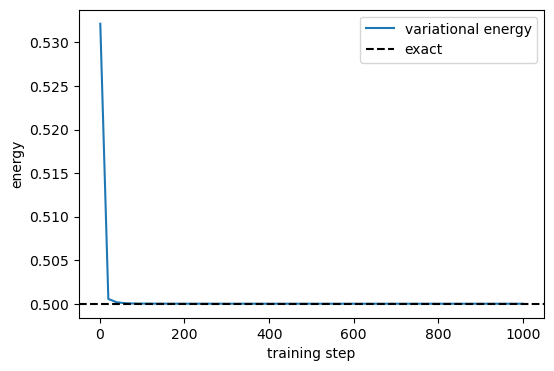

In [8]:
steps = [r.step for r in history]
energies = [r.energy for r in history]

plt.figure(figsize=(6, 4))
plt.plot(steps, energies, label="variational energy")
plt.axhline(exact["energy"], color="black", linestyle="--", label="exact")
plt.xlabel("training step")
plt.ylabel("energy")
plt.legend();

In [9]:
benchmark_table = {
    "energy": (obs.energy, exact["energy"], obs.energy - exact["energy"]),
    "x2 / G(0)": (obs.x2, exact["x2"], obs.x2 - exact["x2"]),
    "x4": (obs.x4, exact["x4"], obs.x4 - exact["x4"]),
    "local energy variance": (obs.local_energy_variance, 0.0, obs.local_energy_variance),
    "virial residual": (obs.virial_residual, 0.0, obs.virial_residual),
}
benchmark_table

{'energy': (0.5000001292922452, 0.5, 1.2929224524338423e-07),
 'x2 / G(0)': (0.500004347254392, 0.5, 4.347254392023103e-06),
 'x4': (0.7500563400452678, 0.75, 5.634004526777758e-05),
 'local energy variance': (1.278294984017834e-06, 0.0, 1.278294984017834e-06),
 'virial residual': (-8.435924293559438e-06, 0.0, -8.435924293559438e-06)}

For the exact harmonic oscillator ground state,

$$
G(\tau)=\langle x(\tau)x(0)\rangle=\frac{1}{2\omega}e^{-\omega\tau}.
$$

The learned ground state directly checks only $G(0)=\langle x^2\rangle$. Reconstructing nontrivial correlators from learned states requires excited-state wavefunctions and transition matrix elements, which is outside v1.

The correlator can also be approximated without explicitly computing excited states.  The helper below forms the source state $x\psi_0$, builds a Krylov/Lanczos approximation to $\exp[-\tau(H-E_0)]$, and evaluates $\langle x\psi_0|\exp[-\tau(H-E_0)]|x\psi_0\rangle$.

{'krylov_iterations': 8,
 'source_norm_squared / G(0)': 0.5000043472543924,
 'learned_x2': 0.500004347254392,
 'max_abs_error_vs_exact': 4.899528816881826e-06}

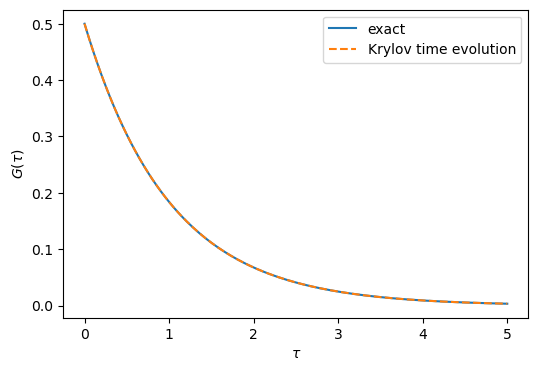

In [20]:
from adjoint_qm import dirichlet_grid_1d, krylov_spectrum, position_correlator_time_evolution_1d

tau_time = torch.linspace(0.0, 5.0, 200)
time_grid, time_weights = dirichlet_grid_1d(x_max=8.0, n_grid=1600)
g_time, time_evolution = position_correlator_time_evolution_1d(
    model,
    potential,
    time_grid,
    time_weights,
    tau_time,
    energy_shift=obs.energy,
    krylov_dim=8,
    tol=1.0e-4,
)
g_exact_time = harmonic_correlator(tau_time, omega=omega)
max_abs_error = torch.max(torch.abs(g_time - g_exact_time)).item()

plt.figure(figsize=(6, 4))
plt.plot(tau_time.numpy(), g_exact_time.numpy(), label="exact")
plt.plot(tau_time.numpy(), g_time.detach().numpy(), linestyle="--", label="Krylov time evolution")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$G(\tau)$")
plt.legend();

time_evolution_table = {
    "krylov_iterations": time_evolution.iterations,
    "source_norm_squared / G(0)": float(time_evolution.source_norm.detach() ** 2),
    "learned_x2": obs.x2,
    "max_abs_error_vs_exact": max_abs_error,
}
time_evolution_table

Diagonalizing the small Lanczos matrix gives Ritz energy estimates in the source sector.  These are not the full oscillator spectrum; they are the energies that have nonzero overlap with the source state $x\psi_0$ in this Krylov approximation.

In [21]:
spectrum = krylov_spectrum(time_evolution, energy_shift=obs.energy)

source_sector_energies = [
    {
        "ritz_index": n,
        "energy": float(spectrum.energies[n]),
        "gap_from_ground": float(spectrum.gaps[n]),
        "spectral_weight": float(spectrum.spectral_weights[n]),
        "normalized_source_weight": float(spectrum.normalized_weights[n]),
    }
    for n in range(spectrum.energies.numel())
    if spectrum.spectral_weights[n] > 1.0e-10
]
source_sector_energies

[{'ritz_index': 0,
  'energy': 1.499984503671848,
  'gap_from_ground': 0.9999843743796027,
  'spectral_weight': 0.5000041630396751,
  'normalized_source_weight': 0.9999996315737687},
 {'ritz_index': 1,
  'energy': 9.526825853443562,
  'gap_from_ground': 9.026825724151317,
  'spectral_weight': 1.8381314743804387e-07,
  'normalized_source_weight': 3.6762309857382773e-07},
 {'ritz_index': 2,
  'energy': 37.51432840955868,
  'gap_from_ground': 37.01432828026643,
  'spectral_weight': 3.98736702144097e-10,
  'normalized_source_weight': 7.97466470708959e-10}]

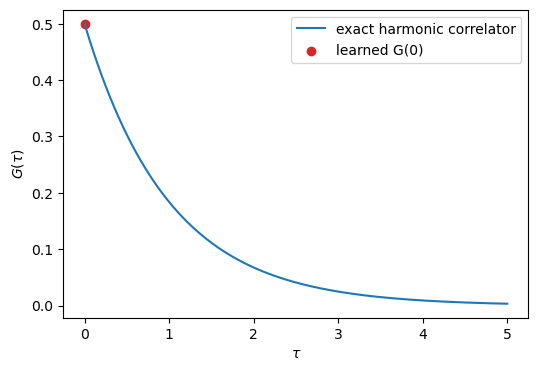

In [11]:
tau = torch.linspace(0.0, 5.0, 200)
g_tau = harmonic_correlator(tau, omega=omega)

plt.figure(figsize=(6, 4))
plt.plot(tau.numpy(), g_tau.numpy(), label="exact harmonic correlator")
plt.scatter([0.0], [obs.x2], color="tab:red", label="learned G(0)")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$G(\tau)$")
plt.legend();